<a href="https://colab.research.google.com/github/taisei0223/QI4U-hands-on/blob/main/QI4U.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**
**Workshop**:

Quantum Hamiltonian Learning for Financial Forecasting

**Objective**:

To uncover the hidden "Equations of Motion" (Hamiltonian) governing the stock market using Quantum Spectral Decomposition.

**Method**:

Based on the research "Application of time-series quantum generative model to financial data" [(arXiv:2405.11795)](https://arxiv.org/abs/2405.11795).

**Key Concept**:

We treat stock price fluctuations as a quantum wavepacket evolution governed by $U(t) = e^{-iHt}$.

#**Phase 1**

# **Section 1: Install and Import Libraries**
**Purpose:**

Setup the environment for Quantum Hamiltonian Learning.

**Libraries:**

We install and import essential libraries:

**・qiskit:** For building quantum circuits.

**・yfinance:** For fetching real-world stock data.

**・scipy.optimize:** For training the quantum parameters.




In [1]:
# [Cell 1] Install and Import Libraries
# Purpose: Setup the environment for Quantum Hamiltonian Learning.

!pip install qiskit qiskit-aer qiskit-algorithms numpy scipy matplotlib pandas yfinance scikit-learn pylatexenc tqdm 2>/dev/null

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
from scipy.optimize import minimize
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("Libraries installed and imported successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.1 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=f5ee070076b13e9109a8c37e789e309a6c6f7c6215d3e41c7f3de4e849991539
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
Libraries installed and imported successfully.


# **Section 2: Data Preparation**
**Train-Test Split:**

We separate the data into "Past (Train)" for learning and "Future (Test)" for validation to ensure fair evaluation.

**Log-Returns:**

We analyze relative changes $r_t = \ln(P_{t+1}/P_t)$ rather than raw prices.

**Discretization:**

Continuous returns are mapped into $2^n$ discrete quantum states (bins) to be processed by $n$ qubits.

**Ground Truth:**

We calculate the real transition matrix $P_{real}(x_{t+1}|x_t)$ as the target for our Hamiltonian learning.

# **Major US stocks list**
First of all, you should select **SPY**. After then, you can change ticker ="any other stock NAME"

**1. Major Market Index ETFs (Macroscopic Systems)**

These represent large collections of stocks and are excellent for modeling thermodynamic-like, macroscopic market behavior.

**・SPY**: SPDR S&P 500 ETF Trust (Tracks the top 500 US companies)

**・QQQ**: Invesco QQQ Trust (Tracks the NASDAQ-100; heavy on tech stocks)

**・DIA**: SPDR Dow Jones Industrial Average ETF (Tracks 30 blue-chip US companies)

**・IWM**: iShares Russell 2000 ETF (Tracks 2000 small-cap US companies)

**2. Mega-Cap Tech & AI (High Liquidity & Volatility)**

These individual stocks have massive trading volumes, making them prime targets for options trading and capturing short-term volatility.

**・AAPL**: Apple Inc.

**・MSFT**: Microsoft Corporation

**・AMZN**: Amazon.com, Inc.

**・GOOGL** (or GOOG): Alphabet Inc. (Google)

**・TSLA**: Tesla, Inc.

**・NVDA**: NVIDIA Corporation

**・META**: Meta Platforms, Inc. (formerly Facebook)

**3. Precious Metals & Commodity ETFs**

These assets often act differently from tech stocks and are useful for diversifying predictive models or hedging.

**・SLV**: iShares Silver Trust (Tracks the price of silver)

**・GLD**: SPDR Gold Shares (Tracks the price of gold)

**・USO**: United States Oil Fund (Tracks the price of crude oil)

**4. Semiconductors & Hardware**

**・AMD**: Advanced Micro Devices, Inc.

**・INTC**: Intel Corporation

**・TSM**: Taiwan Semiconductor Manufacturing Company (ADR)

In [2]:
# [Cell 2] Data Loading & Preprocessing

# Settings
# ticker = "AAPL"
ticker ="SPY"
n_qubits = 4
n_bins = 2**n_qubits
test_days = 30

print(f"Fetching data for {ticker}...")

# 1. Fetch Data
data = yf.download(ticker, start="2024-01-01", end="2025-01-01", progress=False)
if isinstance(data.columns, pd.MultiIndex):
    prices = data['Close'].iloc[:, 0].values.flatten()
else:
    prices = data['Close'].values.flatten()

# 2. Split Data
train_prices = prices[:-test_days]
test_prices = prices[-test_days:]

# 3. Calculate Log-Returns on Training Data
log_returns_train = np.log(train_prices[1:] / train_prices[:-1])
log_returns_train = np.nan_to_num(log_returns_train)

# 4. Discretization
mean_val = np.mean(log_returns_train)
std_val = np.std(log_returns_train)
min_val = mean_val - 3 * std_val
max_val = mean_val + 3 * std_val

bins = np.linspace(min_val, max_val, n_bins + 1)
digitized = np.digitize(log_returns_train, bins) - 1
digitized = np.clip(digitized, 0, n_bins - 1)

# 5. Ground Truth Transition Matrix
transition_matrix_real = np.zeros((n_bins, n_bins))
for i in range(len(digitized)-1):
    curr = digitized[i]
    next_s = digitized[i+1]
    transition_matrix_real[next_s, curr] += 1

col_sums = transition_matrix_real.sum(axis=0)
transition_matrix_real = np.divide(
    transition_matrix_real,
    col_sums,
    out=np.zeros_like(transition_matrix_real),
    where=col_sums!=0
)

print(f"Data Prepared. Train: {len(train_prices)}, Test: {len(test_prices)}")

Fetching data for SPY...
Data Prepared. Train: 222, Test: 30


# **Phase 2**



# **Section 3: Quantum Ansatz**

**Theory:** We model the time evolution operator as $U(t) = V D(t) V^\dagger$.

・$V(\theta)$ (Basis Change): Maps the computational basis to the Hamiltonian's eigenbasis. This circuit learns the spatial structure and correlations (entanglement).

・$D(t)$ (Time Evolution): A diagonal matrix representing phase rotation $e^{-i E_k t}$. This allows us to simulate continuous time $t$ simply by scaling the rotation angle.

In [3]:
# [Cell 3] Define Quantum Ansatz
def create_spectral_circuit(n_qubits, params_v, params_lambda, t=1.0):
    qc = QuantumCircuit(n_qubits)

    # --- V (Basis Change) ---
    qc_v = QuantumCircuit(n_qubits, name="V")
    n_layers_v = 4

    p_idx = 0
    for _ in range(n_layers_v):
        for q in range(n_qubits):
            qc_v.ry(params_v[p_idx], q)
            p_idx += 1
        for q in range(n_qubits-1):
            qc_v.cx(q, q+1)
        qc_v.cx(n_qubits-1, 0)

    qc.compose(qc_v, inplace=True)
    qc.barrier()

    # --- D(t) (Diagonal Evolution) ---
    for q in range(n_qubits):
        qc.rz(2 * params_lambda[q] * t, q)

    qc.barrier()

    # --- V_dagger ---
    qc.compose(qc_v.inverse(), inplace=True)

    return qc

print("Ansatz defined.")

Ansatz defined.


# **Cell 4: Circuit Visualization**

**Purpose:**

Inspect the structure of the quantum model.

**Structure:**

You can see the symmetric structure of $V$ (encoding) -> $D(t)$ (evolution) -> $V^\dagger$ (decoding). This "sandwich" structure is the hallmark of spectral decomposition.

=== Quantum Circuit Diagram ===


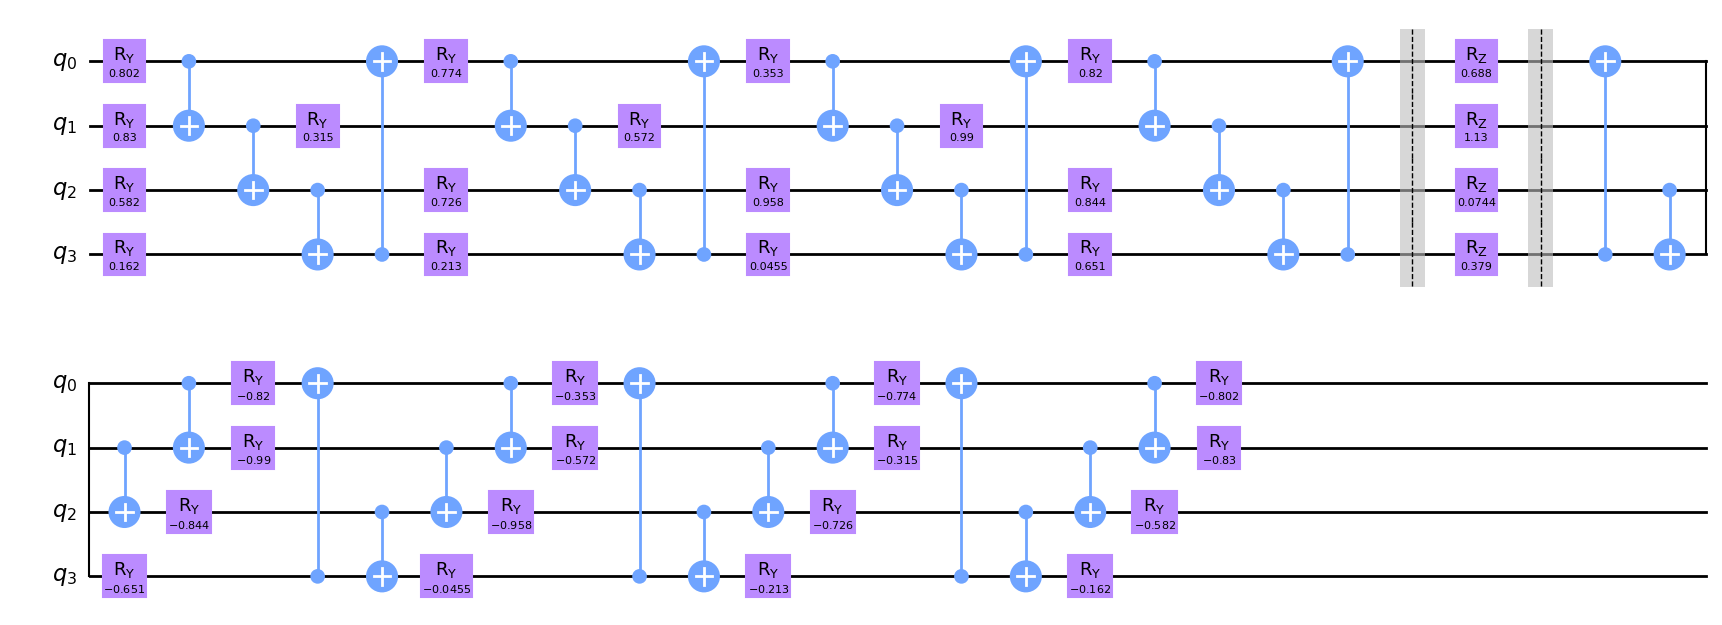

In [4]:
# [Cell 4] Visualize the Circuit
n_layers_v = 4
n_params_v = n_qubits * n_layers_v
n_params_lambda = n_qubits

# Generate dummy parameters for visualization
dummy_v = np.random.rand(n_params_v)
dummy_lam = np.random.rand(n_params_lambda)

# Draw circuit
qc_sample = create_spectral_circuit(n_qubits, dummy_v, dummy_lam, t=1.0)
print("=== Quantum Circuit Diagram ===")
qc_sample.draw(output='mpl', style='clifford')

# **Phase 3**

# **Cell 5: Hamiltonian Learning**

**Goal:**

Find the optimal Hamiltonian ($H_\text{eff}$) that minimizes the difference between the quantum dynamics and real market data.

**Loss Function:**

We use MMD (Maximum Mean Discrepancy) to measure the distance between the two probability distributions.

**Process:**

The optimizer adjusts the eigenvalues and eigenvectors to fit the market's diffusion process.

Starting Optimization...
Training Complete.


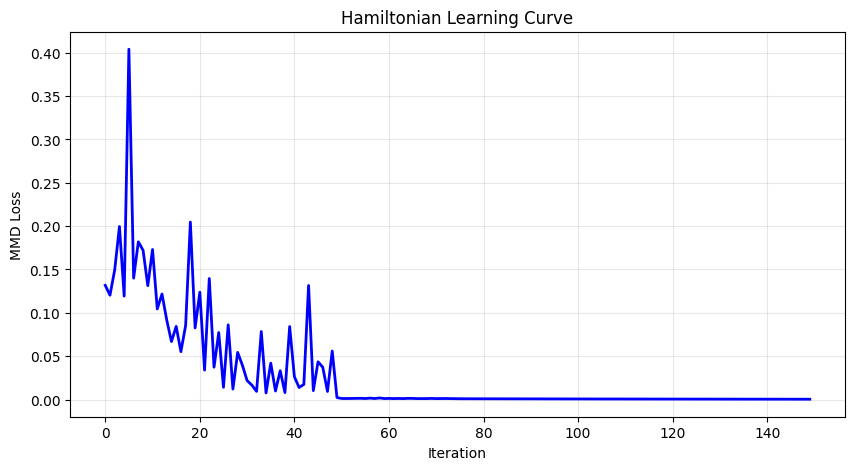

In [5]:
# [Cell 5] Train the Model

# Parameters
n_layers_v = 4
n_params_v = n_qubits * n_layers_v
n_params_lambda = n_qubits
total_params = n_params_v + n_params_lambda

# Loss Function (MMD)
def mmd_loss(probs_p, probs_q, sigma=4.0):
    x = np.arange(len(probs_p)).reshape(-1, 1)
    dists = (x - x.T)**2
    K = np.exp(-dists / (2 * sigma**2))
    return probs_p.T @ K @ probs_p - 2 * probs_p.T @ K @ probs_q + probs_q.T @ K @ probs_q

# Target
center_idx = n_bins // 2
target_dist = transition_matrix_real[:, center_idx]

# History for plotting
loss_history = []

def objective_function(params):
    p_v = params[:n_params_v]
    p_lam = params[n_params_v:]

    qc = create_spectral_circuit(n_qubits, p_v, p_lam, t=1.0)
    init_vec = np.zeros(2**n_qubits)
    init_vec[center_idx] = 1.0
    sv = Statevector(init_vec).evolve(qc)
    probs_qc = np.abs(sv_evolved := sv.data)**2
    # Note: Statevector.data returns complex amplitudes.
    # We take abs()**2 for probabilities.
    probs_qc = np.abs(sv.data)**2

    loss = mmd_loss(probs_qc, target_dist)
    loss_history.append(loss)
    return loss

# Optimization
print("Starting Optimization...")
init_params = np.random.uniform(0, 2*np.pi, total_params)
res = minimize(objective_function, init_params, method='COBYLA', options={'maxiter': 150})
opt_params = res.x

print("Training Complete.")

# --- Plot Loss Curve ---
plt.figure(figsize=(10, 5))
plt.plot(loss_history, color='blue', linewidth=2)
plt.title("Hamiltonian Learning Curve")
plt.xlabel("Iteration")
plt.ylabel("MMD Loss")
plt.grid(True, alpha=0.3)
plt.show()

# **Cell 6: Validation**

**Blue (Real Data):**

Histogram of probability distribution from real log return data

**Right (Quantum Model): T**

Histogram of generated probability distribution from Quantum Born Machine

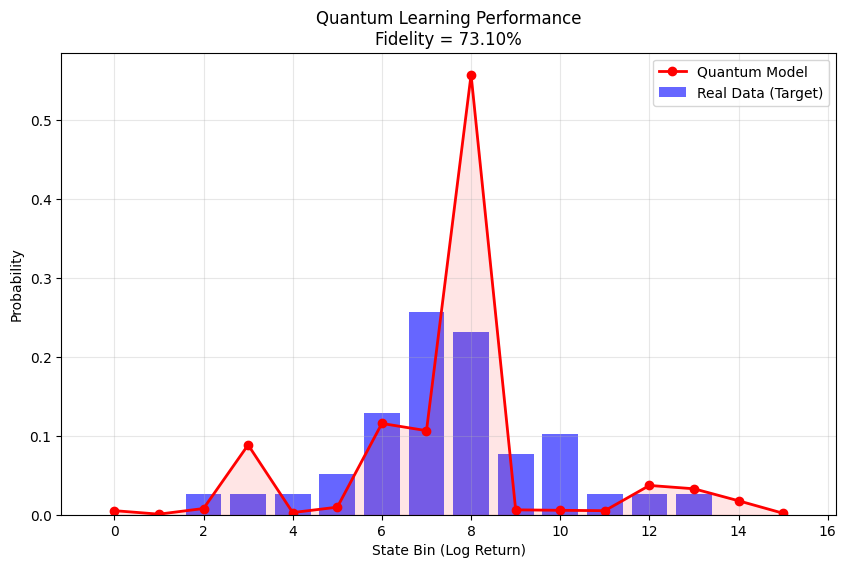

In [6]:
# [Cell 6] Validation: Histogram Comparison

# Reconstruct Quantum Distribution
p_v = opt_params[:n_params_v]
p_lam = opt_params[n_params_v:]
qc = create_spectral_circuit(n_qubits, p_v, p_lam, t=1.0)
init_vec = np.zeros(2**n_qubits)
init_vec[center_idx] = 1.0
sv = Statevector(init_vec).evolve(qc)
quantum_dist = np.abs(sv.data)**2

# Fidelity Calculation
fidelity = np.sum(np.sqrt(target_dist * quantum_dist)) ** 2

# Plot (Original Style: Blue Bars + Red Line)
plt.figure(figsize=(10, 6))
states = np.arange(n_bins)

# Real Data (Blue Bars)
plt.bar(states, target_dist, alpha=0.6, color='blue', label='Real Data (Target)', width=0.8)

# Quantum Model (Red Line with markers)
plt.plot(states, quantum_dist, color='red', marker='o', linewidth=2, label='Quantum Model')
plt.fill_between(states, quantum_dist, color='red', alpha=0.1)

plt.title(f"Quantum Learning Performance\nFidelity = {fidelity:.2%}")
plt.xlabel("State Bin (Log Return)")
plt.ylabel("Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#**Phase 4**

# **Cell 7: Future Prediction (Simulation)**

**Quantum Scenarios (Orange):**

Represent the spreading of the quantum wavepacket, showing market risk/uncertainty.

**Quantum Average (Red Dashed):**

According to Ehrenfest's Theorem, the expectation value $\langle x \rangle$ follows the classical trend. We use this as our prediction.

**ACTUAL Future (Green):**

The real stock price (Test Data) that was hidden during training.Result: Compare the Red Dashed Line with the Green Line to see the predictive power of the Quantum Hamiltonian.

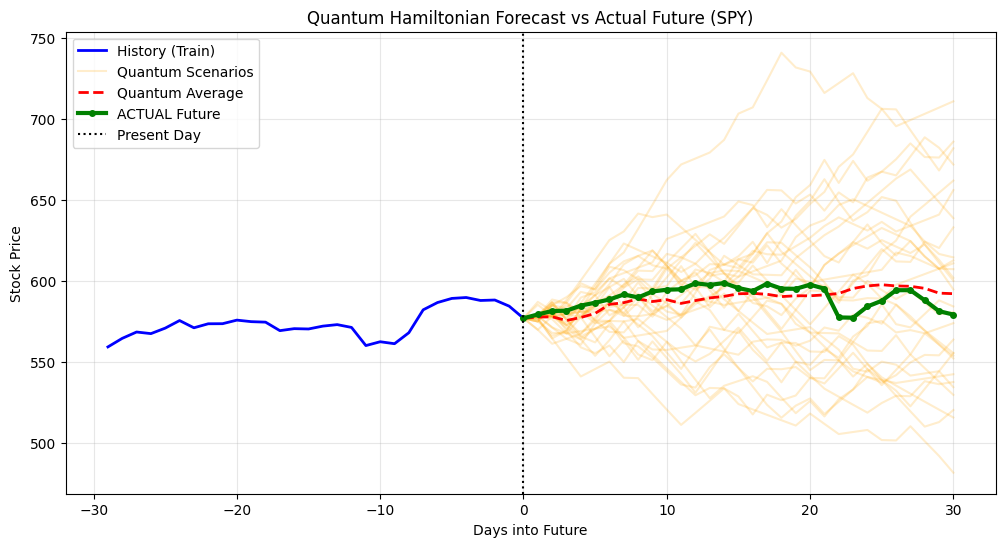

In [9]:
# [Cell 7] Future Prediction (Connected)

# Reconstruct Transition Matrix
transition_matrix_quantum = np.zeros((n_bins, n_bins))
for i in range(n_bins):
    vec = np.zeros(2**n_qubits); vec[i] = 1.0
    qc = create_spectral_circuit(n_qubits, p_v, p_lam, t=1.0)
    sv = Statevector(vec).evolve(qc)
    transition_matrix_quantum[:, i] = np.abs(sv.data)**2

def generate_quantum_paths(start_price, days, n_paths=30):
    paths = []

    def step_quantum(current_bin):
        probs = transition_matrix_quantum[:, current_bin]
        return np.random.choice(np.arange(n_bins), p=probs)

    current_bin = center_idx

    for _ in range(n_paths):
        # *** Connection Fix: Start path with the last known price ***
        path = [start_price]
        curr_p = start_price
        curr_b = current_bin

        for _ in range(days):
            next_b = step_quantum(curr_b)
            r = (bins[next_b] + bins[next_b+1]) / 2
            curr_p = curr_p * np.exp(r)
            path.append(curr_p)
            curr_b = next_b
        paths.append(path)
    return np.array(paths)

# Generate
future_scenarios = generate_quantum_paths(train_prices[-1], days=test_days)
mean_quantum_path = np.mean(future_scenarios, axis=0)

# Plot
plt.figure(figsize=(12, 6))

# 1. History (Blue) - Last 30 days of training data
history_x = np.arange(-29, 1) # Ends at 0
plt.plot(history_x, train_prices[-30:], color='blue', linewidth=2, label='History (Train)')

# 2. Quantum Scenarios (Orange) - Starts at 0
future_x = np.arange(0, test_days + 1)
for i, path in enumerate(future_scenarios):
    lbl = 'Quantum Scenarios' if i == 0 else ""
    plt.plot(future_x, path, color='orange', alpha=0.2, label=lbl)

# 3. Quantum Average (Red Dashed)
plt.plot(future_x, mean_quantum_path, color='red', linestyle='--', linewidth=2, label='Quantum Average')

# 4. Actual Future (Green) - Connected
# Append last train price to connect the green line visually
actual_future_connected = np.concatenate(([train_prices[-1]], test_prices))
plt.plot(future_x, actual_future_connected, color='green', linewidth=3, marker='o', markersize=4, label='ACTUAL Future')

plt.axvline(0, color='black', linestyle=':', label='Present Day')
plt.title(f"Quantum Hamiltonian Forecast vs Actual Future ({ticker})")
plt.xlabel("Days into Future")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# **Appendix**


# **Cell 8: Composite Hilbert Space Construction**

**Purpose:**

To map continuous, classical multi-variable financial data into a discrete composite Hilbert space that can be processed by a quantum circuit.

**Computational Steps:**

**1.Data Fetching:**

Retrieve historical daily closing prices for two distinct assets (SPY and TLT) and compute their logarithmic returns.

**2.Quantization:**

Discretize the continuous return distributions into discrete bins. We assign $3$ qubits per asset, resulting in $2^3 = 8$ discrete states for each.

**3.Tensor Product Space Construction:**

We combine the isolated spaces using a tensor product to form a composite basis $|i_A, i_B\rangle$. This creates a 6-qubit joint space encompassing $64$ possible states.

**Empirical Matrix Generation:**

By counting the historical transitions from one joint state to the next, we construct a $64 \times 64$ empirical transition probability matrix. This serves as the classical target data for our quantum model.

In [ ]:
# [Cell 8] Joint Data Preparation (4-Qubit Space)
import yfinance as yf
import numpy as np

# --- Configuration ---
ticker_A = "SPY"
ticker_B = "TLT"
test_days = 30

# To respect the thermodynamic limit given the small dataset (250 days),
# we strictly limit the Hilbert space to 4 qubits (16 joint states).
n_qubits_per_asset = 3
n_bins_per_asset = 2**n_qubits_per_asset
total_qubits = n_qubits_per_asset * 2
n_joint_states = 2**total_qubits

print(f"Constructing {n_joint_states}-dimensional Joint Hilbert Space...")

data_A = yf.download(ticker_A, start="2023-12-01", end="2025-12-01", progress=False)['Close'].values.flatten()
data_B = yf.download(ticker_B, start="2023-12-01", end="2025-12-01", progress=False)['Close'].values.flatten()

min_len = min(len(data_A), len(data_B))
data_A, data_B = data_A[-min_len:], data_B[-min_len:]
train_A, test_A = data_A[:-test_days], data_A[-test_days:]
train_B, test_B = data_B[:-test_days], data_B[-test_days:]

ret_A = np.nan_to_num(np.log(train_A[1:] / train_A[:-1]))
ret_B = np.nan_to_num(np.log(train_B[1:] / train_B[:-1]))

def discretize_returns(returns, n_bins):
    mean, std = np.mean(returns), np.std(returns)
    bins = np.linspace(mean - 2*std, mean + 2*std, n_bins + 1)
    dig = np.digitize(returns, bins) - 1
    return np.clip(dig, 0, n_bins - 1), bins

dig_A, bins_A = discretize_returns(ret_A, n_bins_per_asset)
dig_B, bins_B = discretize_returns(ret_B, n_bins_per_asset)

# Map to tensor product basis
joint_states = dig_A * n_bins_per_asset + dig_B
trans_mat_joint = np.zeros((n_joint_states, n_joint_states))
for i in range(len(joint_states)-1):
    trans_mat_joint[joint_states[i+1], joint_states[i]] += 1

col_sums = trans_mat_joint.sum(axis=0)
trans_mat_joint = np.divide(trans_mat_joint, col_sums, out=np.zeros_like(trans_mat_joint), where=col_sums!=0)
print("Data Preparation Complete.")

Constructing 64-dimensional Joint Hilbert Space...
Data Preparation Complete.


# **Cell 9: Joint Hamiltonian Optimization (Ising Model)**

**Purpose: **

To define a physical Hamiltonian model governing the coupled assets and optimize its parameters to replicate the empirical joint transition matrix.

**Computational Steps:**

**1.Ansatz Definition:**

 We construct a parameterized time-evolution operator $\hat{U}(t) = V(\theta) e^{-i\hat{D}t} V^\dagger(\theta)$ with $4$ layers. The diagonal matrix $\hat{D}$ includes local $Z$-rotations (Zeeman terms) and, crucially, an Ising interaction term ($J Z_A Z_B$) implemented via an $R_{zz}$ gate to generate quantum entanglement between the assets.

**2.Loss Evaluation:**

We evolve initial statevectors through the circuit and apply Born's rule to extract the quantum transition probabilities. The objective function calculates the Maximum Mean Discrepancy (MMD) loss between these quantum probabilities and the target classical matrix.

**3.Ensemble Optimization:**

To avoid barren plateaus and local minima in the $64$-dimensional space, we execute a multi-start optimization (3 independent runs) using the COBYLA algorithm with up to $1000$ iterations. We select the Hamiltonian with the lowest final loss.

Starting Hamiltonian Optimization (3 runs)...
  Run 1/3: Final Loss = 20.2442
  Run 2/3: Final Loss = 20.3899
  Run 3/3: Final Loss = 20.3168


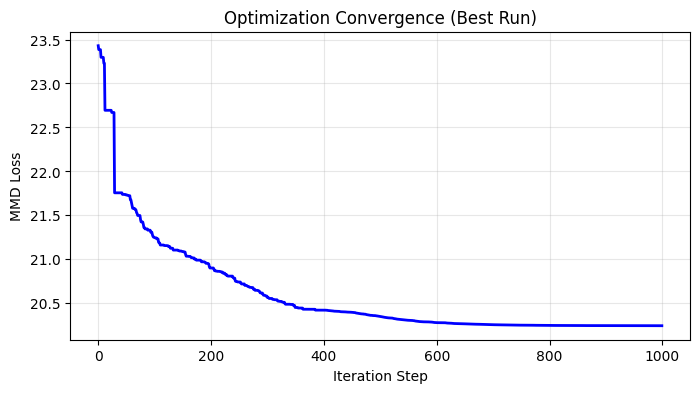

In [ ]:
# [Cell 9] Ensemble Joint Hamiltonian Learning with Convergence Tracking
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration ---
layers = 4
total_params = (total_qubits * layers) + total_qubits + 1

# --- 1. Circuit Definition (Ising Ansatz) ---
def create_ising_circuit(params_v, params_lam, param_J, t=1.0):
    # V(theta): Basis transformation
    qc_v = QuantumCircuit(total_qubits)
    idx = 0
    for _ in range(layers):
        for i in range(total_qubits):
            qc_v.ry(params_v[idx], i)
            idx += 1
        for i in range(total_qubits - 1):
            qc_v.cx(i, i + 1)

    # D(t): Time evolution with Ising interaction
    qc_d = QuantumCircuit(total_qubits)
    for k in range(total_qubits):
        qc_d.rz(2 * params_lam[k] * t, k)

    boundary_A = n_qubits_per_asset - 1
    boundary_B = n_qubits_per_asset
    qc_d.cx(boundary_A, boundary_B)
    qc_d.rz(2 * param_J * t, boundary_B)
    qc_d.cx(boundary_A, boundary_B)

    # U = V * D * V^\dagger
    qc = QuantumCircuit(total_qubits)
    qc.compose(qc_v, inplace=True)
    qc.compose(qc_d, inplace=True)
    qc.compose(qc_v.inverse(), inplace=True)

    return qc

# --- 2. Objective Function with Loss Tracking ---
current_run_history = []

def mmd_loss_joint_full(params):
    p_v = params[:total_qubits * layers]
    p_lam = params[total_qubits * layers : total_qubits * layers + total_qubits]
    p_J = params[-1]

    loss = 0.0
    for i in range(n_joint_states):
        init_vec = np.zeros(n_joint_states)
        init_vec[i] = 1.0
        qc = create_ising_circuit(p_v, p_lam, p_J, t=1.0)
        sv = Statevector(init_vec).evolve(qc)
        probs_qc = np.abs(sv.data)**2
        loss += np.sum((probs_qc - trans_mat_joint[:, i])**2)

    current_run_history.append(loss)
    return loss

# --- 3. Optimization (Multi-start) ---
n_runs = 3
print(f"Starting Hamiltonian Optimization ({n_runs} runs)...")

best_loss = float('inf')
best_params = None
best_history = []

np.random.seed(42)

for run in range(n_runs):
    current_run_history = []
    init_params = np.random.uniform(0, 2*np.pi, total_params)

    res = minimize(mmd_loss_joint_full, init_params, method='COBYLA', options={'maxiter': 1000})

    print(f"  Run {run+1}/{n_runs}: Final Loss = {res.fun:.4f}")

    if res.fun < best_loss:
        best_loss = res.fun
        best_params = res.x
        # Store the monotonically decreasing best loss array for plotting
        best_history = np.minimum.accumulate(current_run_history)

opt_params = best_params

# --- 4. Plot Convergence ---
plt.figure(figsize=(8, 4))
plt.plot(best_history, color='blue', linewidth=2)
plt.title("Optimization Convergence (Best Run)")
plt.xlabel("Iteration Step")
plt.ylabel("MMD Loss")
plt.grid(True, alpha=0.3)
plt.show()

# **Cell 10: Coupled Forecast & Portfolio Correlation**

**Purpose:**

To decode the optimized quantum state back into classical financial metrics, simulating future macroeconomic trajectories and portfolio correlation.

**Computational Steps:**

**1.Matrix Reconstruction:**

We execute the optimized quantum circuit to strictly compute the final $64 \times 64$ quantum transition probability matrix.

**2.Wavefunction Collapse (Path Generation):**

Starting from the present day's state, we probabilistically sample the next state according to the quantum matrix. We repeat this process to generate $100$ Monte Carlo paths over $30$ days, decoding the joint states back into individual asset prices.

**Macroscopic Observables:**

We calculate the ensemble average of these paths. According to Ehrenfest's theorem, this expectation value yields the deterministic classical drift. We also compute the trajectory of a mixed portfolio (50% SPY / 50% TLT).

**Correlation Extraction:**

We calculate the Pearson correlation coefficient ($\rho$) from the simulated return distributions on the final day, visualizing how effectively the Ising interaction mathematically captured the real-world covariance.

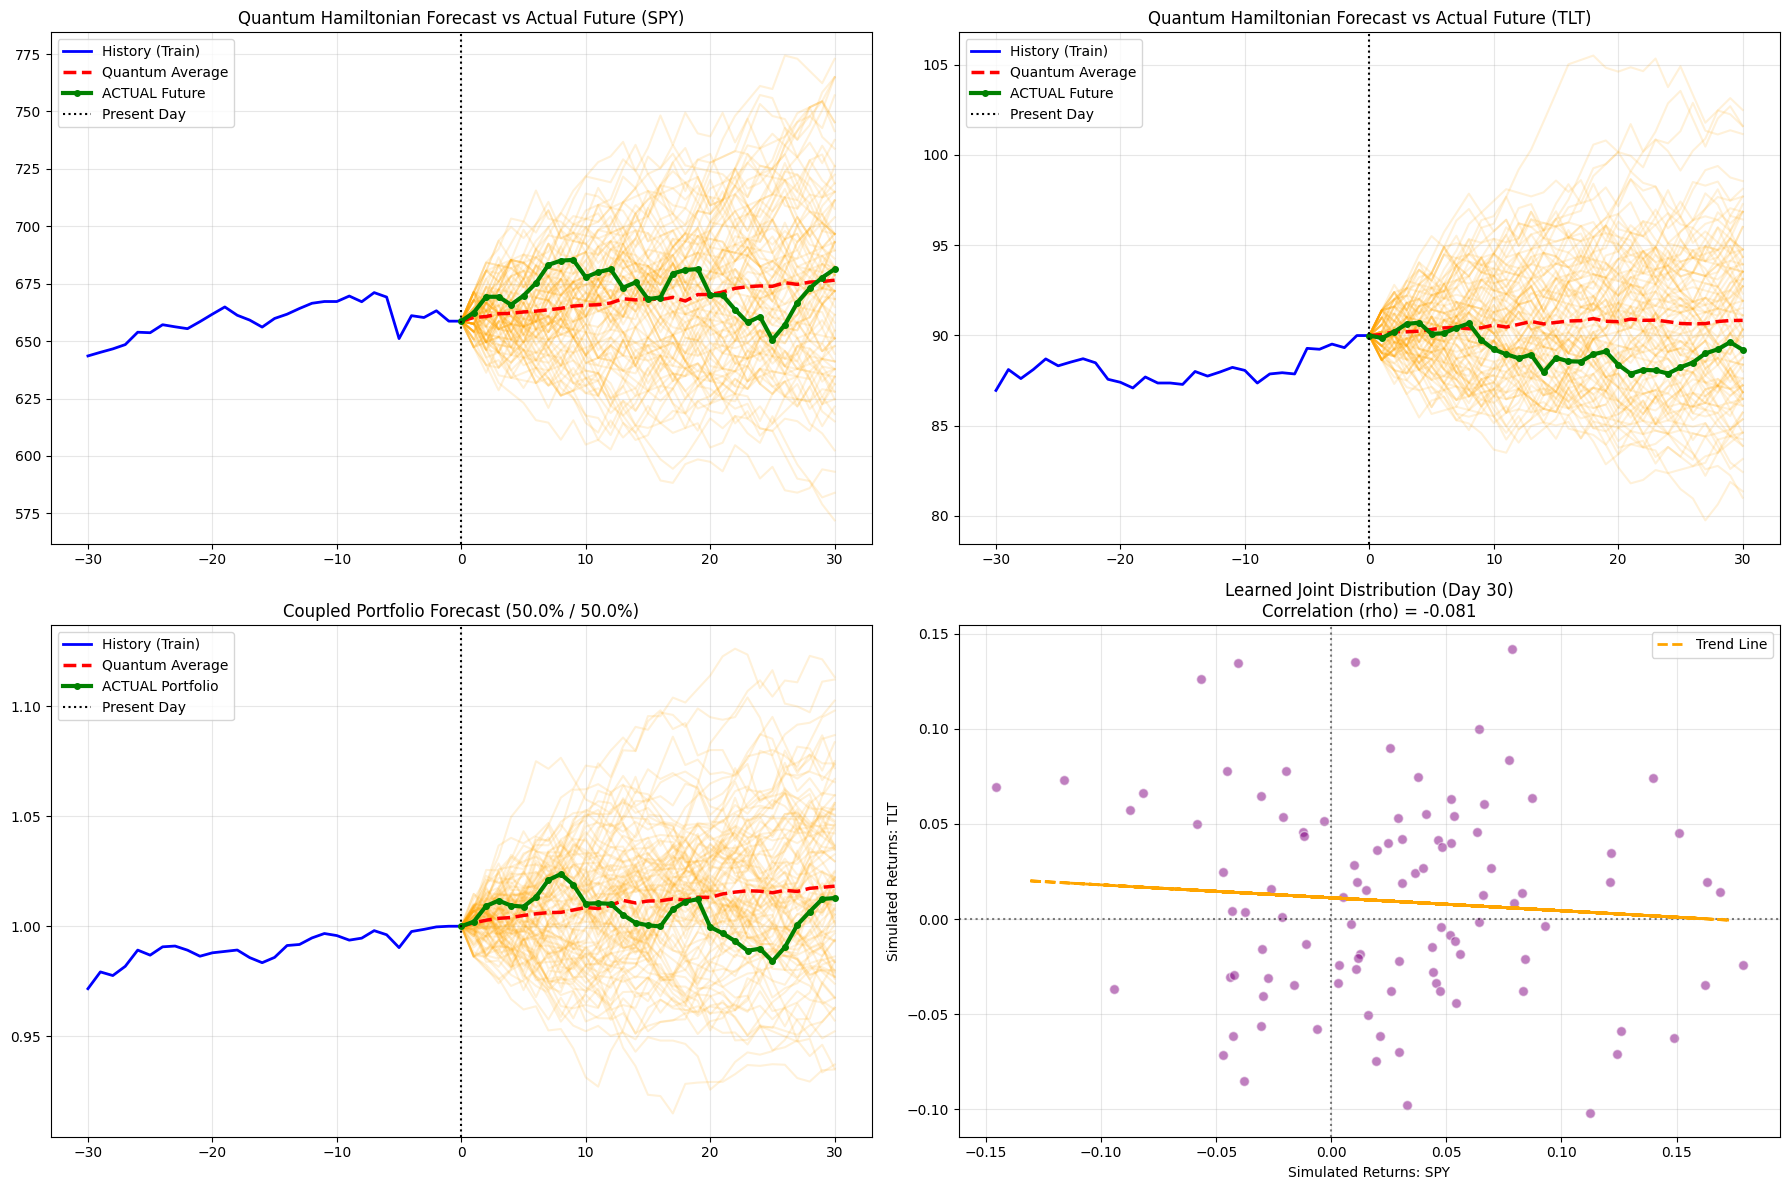

In [ ]:
# [Cell 10] Quantum Ensemble Forecast & Correlation Analysis
import matplotlib.pyplot as plt
import numpy as np

n_paths = 100
weight_A = 0.5
weight_B = 0.5
history_days = 30

# 1. Reconstruct Optimal Joint Transition Matrix
p_v = opt_params[:total_qubits * layers]
p_lam = opt_params[total_qubits * layers : total_qubits * layers + total_qubits]
p_J = opt_params[-1]

qc_opt_joint = np.zeros((n_joint_states, n_joint_states))
for i in range(n_joint_states):
    init_vec = np.zeros(n_joint_states)
    init_vec[i] = 1.0
    qc = create_ising_circuit(p_v, p_lam, p_J, t=1.0)
    sv = Statevector(init_vec).evolve(qc)
    qc_opt_joint[:, i] = np.abs(sv.data)**2

# 2. Simulate Generative Quantum Paths (Wavefunction Collapse)
paths_A, paths_B = [], []
start_state = joint_states[-1]

for _ in range(n_paths):
    path_A = [train_A[-1]]
    path_B = [train_B[-1]]
    curr_s = start_state
    curr_price_A = train_A[-1]
    curr_price_B = train_B[-1]

    for _ in range(test_days):
        # Measure next state based on quantum probability
        next_s = np.random.choice(np.arange(n_joint_states), p=qc_opt_joint[:, curr_s])

        # Decode tensor product state into individual asset states
        next_bin_A = next_s // n_bins_per_asset
        next_bin_B = next_s % n_bins_per_asset

        # Convert state bins back to log-returns
        r_A = (bins_A[next_bin_A] + bins_A[next_bin_A+1]) / 2
        r_B = (bins_B[next_bin_B] + bins_B[next_bin_B+1]) / 2

        # Apply returns to prices
        curr_price_A *= np.exp(r_A)
        curr_price_B *= np.exp(r_B)

        path_A.append(curr_price_A)
        path_B.append(curr_price_B)
        curr_s = next_s

    paths_A.append(path_A)
    paths_B.append(path_B)

paths_A = np.array(paths_A)
paths_B = np.array(paths_B)

# 3. Statistics Calculation (Mean of the ensemble)
mean_A = np.mean(paths_A, axis=0)
mean_B = np.mean(paths_B, axis=0)

# Portfolio calculation normalized to Day 0
norm_paths_A = paths_A / paths_A[:, 0][:, None]
norm_paths_B = paths_B / paths_B[:, 0][:, None]
portfolio_paths = weight_A * norm_paths_A + weight_B * norm_paths_B

mean_Port = np.mean(portfolio_paths, axis=0)

# Actual future data
actual_A = np.concatenate(([train_A[-1]], test_A))
actual_B = np.concatenate(([train_B[-1]], test_B))
actual_Port = weight_A * (actual_A / actual_A[0]) + weight_B * (actual_B / actual_B[0])

# History data for plotting
hist_x = np.arange(-history_days, 1)
hist_A_plot = np.append(train_A[-history_days:], train_A[-1])
hist_B_plot = np.append(train_B[-history_days:], train_B[-1])
hist_Port_plot = weight_A * (hist_A_plot / train_A[-1]) + weight_B * (hist_B_plot / train_B[-1])

# Calculate learned correlation from the final distribution
ret_A = norm_paths_A[:, -1] - 1
ret_B = norm_paths_B[:, -1] - 1
correlation = np.corrcoef(ret_A, ret_B)[0, 1]

# 4. Visualization (Strictly Part 1 Style)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
future_x = np.arange(0, test_days + 1)

# Plot A: Asset A Forecast
axes[0, 0].plot(hist_x, hist_A_plot, color='blue', linewidth=2, label='History (Train)')
for p in paths_A:
    axes[0, 0].plot(future_x, p, color='orange', alpha=0.15)
axes[0, 0].plot(future_x, mean_A, color='red', linewidth=2.5, linestyle='--', label='Quantum Average')
axes[0, 0].plot(future_x, actual_A, color='green', linewidth=3, marker='o', markersize=4, label='ACTUAL Future')
axes[0, 0].axvline(0, color='black', linestyle=':', label='Present Day')
axes[0, 0].set_title(f"Quantum Hamiltonian Forecast vs Actual Future ({ticker_A})")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(loc='upper left')

# Plot B: Asset B Forecast
axes[0, 1].plot(hist_x, hist_B_plot, color='blue', linewidth=2, label='History (Train)')
for p in paths_B:
    axes[0, 1].plot(future_x, p, color='orange', alpha=0.15)
axes[0, 1].plot(future_x, mean_B, color='red', linewidth=2.5, linestyle='--', label='Quantum Average')
axes[0, 1].plot(future_x, actual_B, color='green', linewidth=3, marker='o', markersize=4, label='ACTUAL Future')
axes[0, 1].axvline(0, color='black', linestyle=':', label='Present Day')
axes[0, 1].set_title(f"Quantum Hamiltonian Forecast vs Actual Future ({ticker_B})")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(loc='upper left')

# Plot C: Portfolio Forecast
axes[1, 0].plot(hist_x, hist_Port_plot, color='blue', linewidth=2, label='History (Train)')
for p in portfolio_paths:
    axes[1, 0].plot(future_x, p, color='orange', alpha=0.15)
axes[1, 0].plot(future_x, mean_Port, color='red', linewidth=2.5, linestyle='--', label='Quantum Average')
axes[1, 0].plot(future_x, actual_Port, color='green', linewidth=3, marker='o', markersize=4, label='ACTUAL Portfolio')
axes[1, 0].axvline(0, color='black', linestyle=':', label='Present Day')
axes[1, 0].set_title(f"Coupled Portfolio Forecast ({weight_A*100}% / {weight_B*100}%)")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(loc='upper left')

# Plot D: Correlation Scatter Plot
jitter_A = np.random.normal(0, 0.01, size=len(ret_A))
jitter_B = np.random.normal(0, 0.01, size=len(ret_B))
axes[1, 1].scatter(ret_A + jitter_A, ret_B + jitter_B, color='purple', alpha=0.5, edgecolors='white', s=50)
axes[1, 1].set_title(f"Learned Joint Distribution (Day {test_days})\nCorrelation (rho) = {correlation:.3f}")
axes[1, 1].set_xlabel(f"Simulated Returns: {ticker_A}")
axes[1, 1].set_ylabel(f"Simulated Returns: {ticker_B}")
axes[1, 1].axhline(0, color='black', linestyle=':', alpha=0.5)
axes[1, 1].axvline(0, color='black', linestyle=':', alpha=0.5)

m, b = np.polyfit(ret_A, ret_B, 1)
axes[1, 1].plot(ret_A, m*ret_A + b, color='orange', linestyle='--', linewidth=2, label='Trend Line')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()